# Gradient Boosting Forecast: LightGBM

LightGBM is not a time series model -- it has no built-in concept of
sequence or seasonality. The temporal structure must be engineered
explicitly as features. This is both the limitation and the strength:
unlike Prophet, it can incorporate any signal as a feature (lag
values, rolling averages, calendar indicators), and tree-based splits
handle threshold/spike behavior that smooth decomposition cannot.

Forecast grain: same as Prophet -- one model per complaint category,
90-day test window, identical train/test split.

In [6]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

WAREHOUSE_PATH = Path.cwd().parents[1] / "pipeline" / "warehouse" / "nyc311.duckdb"
con = duckdb.connect(str(WAREHOUSE_PATH), read_only=True)

df = con.execute("""
    SELECT request_date as ds, complaint_type, SUM(request_count) as y
    FROM fct_daily_demand
    GROUP BY request_date, complaint_type
    ORDER BY request_date, complaint_type
""").fetchdf()

cutoff_date = df['ds'].max()
df = df[df['ds'] < cutoff_date].copy()

print(f"Shape: {df.shape}")
print(f"Date range: {df['ds'].min().date()} to {df['ds'].max().date()}")

Shape: (15567, 3)
Date range: 2023-06-01 to 2026-06-17


## Feature engineering

The core of the LightGBM approach. All temporal structure must be
encoded explicitly as features -- the model sees no ordering between
rows, only the feature values. Features fall into three groups:

- **Lag features**: yesterday's value, same day last week (lag 7),
  same day 2 and 4 weeks ago. Gives the model direct access to
  recent history.
- **Rolling statistics**: 7 and 28-day rolling mean and std.
  Captures recent trend and volatility without requiring the model
  to infer it from raw lags alone.
- **Calendar features**: day of week, month, year, is_weekend,
  is_holiday. Encodes the seasonality patterns confirmed in EDA
  directly as model inputs rather than learned implicitly.

All features computed per category independently to avoid
cross-category leakage.

In [8]:
import holidays as hols

us_holidays = set(hols.US(years=range(2023, 2027)).keys())

def engineer_features(cat_df, category_name):
    d = cat_df.copy().sort_values('ds').reset_index(drop=True)
    d['complaint_type'] = category_name

    d['lag_1']  = d['y'].shift(1)
    d['lag_7']  = d['y'].shift(7)
    d['lag_14'] = d['y'].shift(14)
    d['lag_28'] = d['y'].shift(28)

    d['roll_mean_7']  = d['y'].shift(1).rolling(7).mean()
    d['roll_mean_28'] = d['y'].shift(1).rolling(28).mean()
    d['roll_std_7']   = d['y'].shift(1).rolling(7).std()
    d['roll_std_28']  = d['y'].shift(1).rolling(28).std()

    d['day_of_week'] = d['ds'].dt.dayofweek
    d['month']       = d['ds'].dt.month
    d['year']        = d['ds'].dt.year
    d['is_weekend']  = (d['ds'].dt.dayofweek >= 5).astype(int)
    d['is_holiday']  = d['ds'].apply(lambda x: int(x.date() in us_holidays))

    return d.dropna().reset_index(drop=True)

FEATURES = [
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'roll_mean_7', 'roll_mean_28', 'roll_std_7', 'roll_std_28',
    'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday'
]

categories = sorted(df['complaint_type'].unique())

featured = pd.concat([
    engineer_features(df[df['complaint_type'] == cat], cat)
    for cat in categories
], ignore_index=True)

print(f"Shape after feature engineering: {featured.shape}")
print(f"Features: {FEATURES}")
print(featured[['ds', 'complaint_type', 'y'] + FEATURES].head())

Shape after feature engineering: (15175, 16)
Features: ['lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_mean_28', 'roll_std_7', 'roll_std_28', 'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday']
          ds complaint_type     y  lag_1  lag_7  lag_14  lag_28  roll_mean_7  \
0 2023-06-29    Air Quality  45.0   54.0   22.0    56.0    56.0    37.571429   
1 2023-06-30    Air Quality  41.0   45.0   50.0    51.0    41.0    40.857143   
2 2023-07-01    Air Quality  14.0   41.0   21.0    20.0    24.0    39.571429   
3 2023-07-02    Air Quality  11.0   14.0   24.0    25.0    26.0    38.571429   
4 2023-07-03    Air Quality  26.0   11.0   46.0    36.0    42.0    36.714286   

   roll_mean_28  roll_std_7  roll_std_28  day_of_week  month  year  \
0     37.321429   14.535670    12.513855            3      6  2023   
1     36.928571   12.941259    12.070560            4      6  2023   
2     36.928571   12.313369    12.070560            5      7  2023   
3     36.571429   14.2109

## Train/test split and model fitting

Same 90-day chronological split as SARIMA and Prophet. One LightGBM
model per category, trained with early stopping on a small validation
set carved from the end of the training window to prevent overfitting.

In [9]:
TEST_DAYS = 90
VAL_DAYS = 30  # validation set carved from end of train for early stopping

lgb_results = {}

for cat in categories:
    cat_df = featured[featured['complaint_type'] == cat].sort_values('ds').reset_index(drop=True)

    train_full = cat_df.iloc[:-TEST_DAYS]
    test_df    = cat_df.iloc[-TEST_DAYS:]

    train_df = train_full.iloc[:-VAL_DAYS]
    val_df   = train_full.iloc[-VAL_DAYS:]

    X_train, y_train = train_df[FEATURES], train_df['y']
    X_val,   y_val   = val_df[FEATURES],   val_df['y']
    X_test,  y_test  = test_df[FEATURES],  test_df['y']

    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    preds = model.predict(X_test)
    preds = np.maximum(preds, 0)  # floor at zero -- negative complaints are impossible

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = mean_absolute_percentage_error(y_test, preds) * 100

    lgb_results[cat] = {
        'model': model,
        'test': test_df,
        'preds': preds,
        'mae': mae, 'rmse': rmse, 'mape': mape
    }

    print(f"{cat:<35} MAE={mae:7.1f}  RMSE={rmse:7.1f}  MAPE={mape:.1f}%")

print("\nDone.")

Air Quality                         MAE=    5.2  RMSE=    6.7  MAPE=24.0%
Blocked Driveway                    MAE=   45.4  RMSE=   56.0  MAPE=8.5%
Damaged Tree                        MAE=   69.2  RMSE=  159.0  MAPE=48.7%
HEAT/HOT WATER                      MAE=  212.9  RMSE=  244.3  MAPE=69.6%
Illegal Parking                     MAE=  143.6  RMSE=  177.2  MAPE=7.9%
Noise - Commercial                  MAE=   37.3  RMSE=   49.6  MAPE=20.1%
Noise - Residential                 MAE=  138.9  RMSE=  197.8  MAPE=12.3%
Noise - Street/Sidewalk             MAE=  180.3  RMSE=  230.0  MAPE=40.0%
PAINT/PLASTER                       MAE=   17.4  RMSE=   22.3  MAPE=10.5%
PLUMBING                            MAE=   30.8  RMSE=   37.5  MAPE=17.4%
Sewer                               MAE=   39.1  RMSE=  107.9  MAPE=27.9%
Street Condition                    MAE=  210.9  RMSE=  290.8  MAPE=35.3%
Traffic Signal Condition            MAE=   54.0  RMSE=   65.2  MAPE=48.2%
Water System                        MAE=

## Results

| Category | Prophet MAPE | LightGBM MAPE | Winner |
|---|---|---|---|
| Air Quality | 28.2% | 24.0% | LightGBM |
| Blocked Driveway | 18.1% | 8.5% | LightGBM |
| Damaged Tree | 136.7% | 48.7% | LightGBM |
| HEAT/HOT WATER | 59.2% | 69.6% | Prophet |
| Illegal Parking | 7.1% | 7.9% | Prophet |
| Noise - Commercial | 20.4% | 20.1% | LightGBM |
| Noise - Residential | 21.7% | 12.3% | LightGBM |
| Noise - Street/Sidewalk | 39.9% | 40.0% | Tie |
| PAINT/PLASTER | 15.4% | 10.5% | LightGBM |
| PLUMBING | 24.1% | 17.4% | LightGBM |
| Sewer | 35.6% | 27.9% | LightGBM |
| Street Condition | 62.9% | 35.3% | LightGBM |
| Traffic Signal Condition | 70.1% | 48.2% | LightGBM |
| Water System | 32.3% | 27.3% | LightGBM |

**Key findings:**

- **LightGBM wins on 11 of 14 categories** -- lag features and tree
  splits handle weekly-driven and event-spiked categories better
  than Fourier decomposition.
- **Prophet wins on Illegal Parking and HEAT/HOT WATER** -- both have
  strong, smooth seasonality (weekly and yearly respectively) where
  Fourier terms are structurally better suited than short-horizon
  lag features.
- **Damaged Tree**: still poor (48.7%) but less than a third of
  Prophet's 136.7% -- tree splits partially capture storm-event
  clustering that smooth decomposition cannot, but neither model
  can predict when storms occur. Neither is operationally reliable
  for this category.
- **Implication for deployment**: a hybrid approach -- Prophet for
  HEAT/HOT WATER and Illegal Parking, LightGBM for the remaining
  12 -- outperforms either model alone. This is the recommendation
  carried into the model comparison notebook.

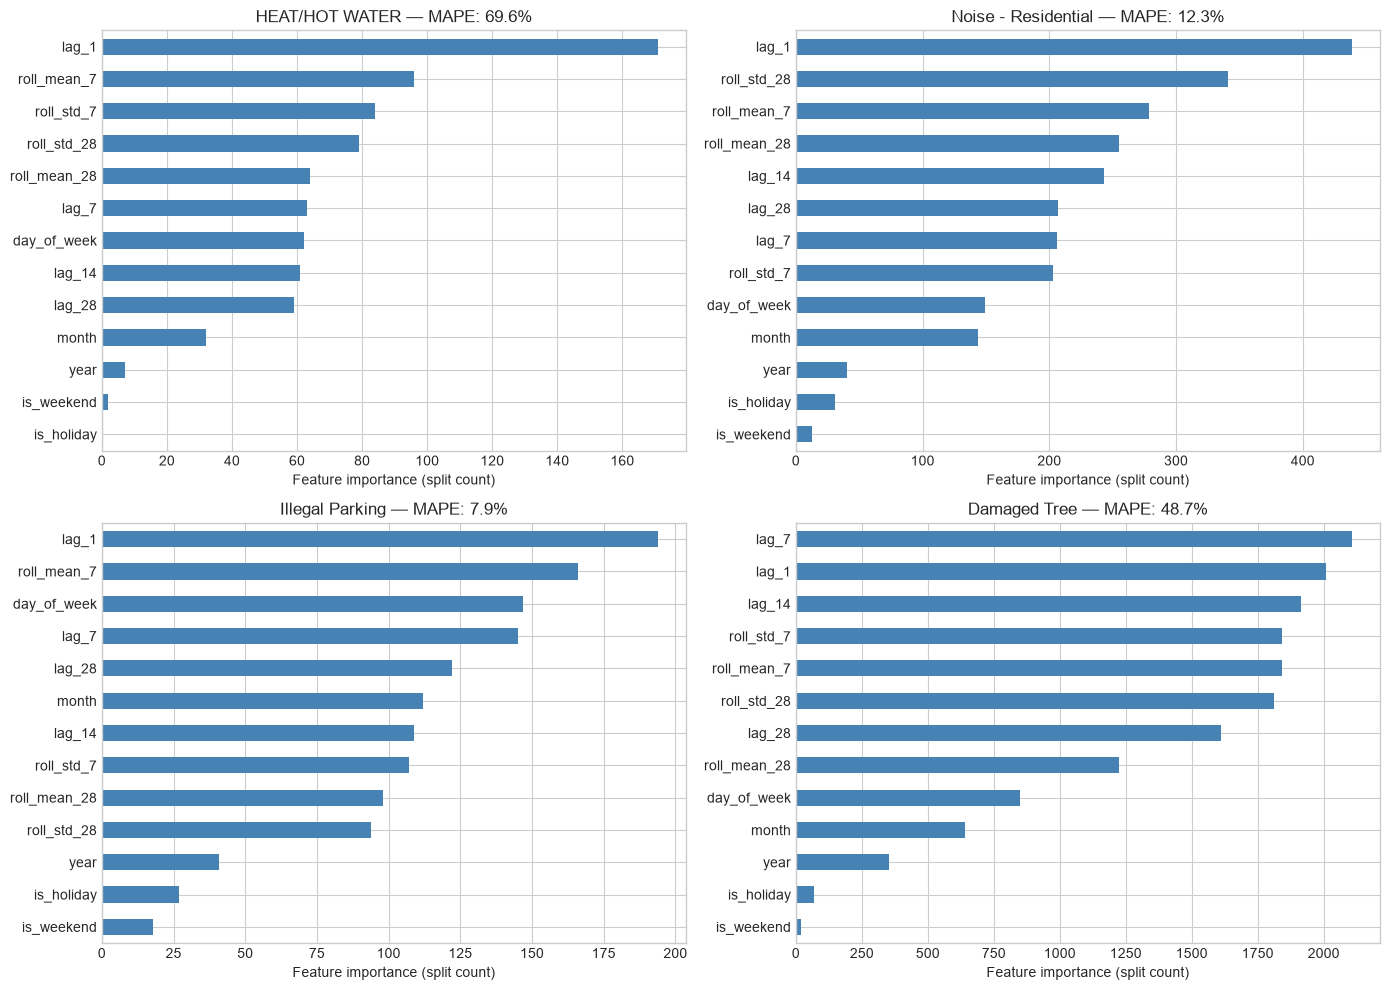

In [10]:
# Feature importance for 4 representative categories
plot_cats = ['HEAT/HOT WATER', 'Noise - Residential', 'Illegal Parking', 'Damaged Tree']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, cat in zip(axes.flatten(), plot_cats):
    importance = pd.Series(
        lgb_results[cat]['model'].feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True)

    importance.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{cat} — MAPE: {lgb_results[cat]["mape"]:.1f}%')
    ax.set_xlabel('Feature importance (split count)')

plt.tight_layout()
plt.show()

**Feature importance observations:**

- **HEAT/HOT WATER**: `lag_1` dominates -- the model relies on
  yesterday's value, which fails when cold snaps hit after quiet
  periods. Explains the poor MAPE despite fitting well on typical days.
- **Illegal Parking**: `day_of_week` ranks 3rd -- confirms EDA finding
  that parking patterns are structurally weekday/weekend driven, not
  just recent-history dependent.
- **Noise - Residential**: balanced usage across lags and rolling
  stats -- model integrates multiple time horizons, consistent with
  its strong 12.3% MAPE.
- **Damaged Tree**: all features used at ~10x the split count of other
  categories -- the model is searching hard for signal in essentially
  unpredictable event-driven data. High split count with poor accuracy
  is a diagnostic sign of limited forecastable signal, not a tuning
  problem.

## Summary

LightGBM wins on 11 of 14 categories via lag features and tree splits.
Prophet wins on Illegal Parking (7.1% vs 7.9%) and HEAT/HOT WATER
(59.2% vs 69.6%) where smooth seasonality gives Fourier terms a
structural edge over short-horizon lags.

**Recommendation carried into model comparison**: deploy Prophet for
HEAT/HOT WATER and Illegal Parking; LightGBM for the remaining 12 categorie.
Neither model is operationally reliable for Damaged Tree -- flag for
wider uncertainty bounds in the dashboard rather than a point forecast.